In [1]:
# Real-World AGN Classification Analysis
# Loading and evaluating the best trained CNN model on real FITS data

import os
import glob
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import re
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define the model architecture (ResNet18 based from the CNN training notebook)
def create_model():
    """Create the same ResNet18 model architecture used in training"""
    model = models.resnet18(pretrained=False)  # We'll load our trained weights
    
    # Modify input conv layer for grayscale (1 channel)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    
    # Modify the final layer for binary classification (NAT=0, WAT=1)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)
    
    return model

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model and load best weights
model = create_model()
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully!")

Using device: cpu


/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully!


In [3]:
# Function to load and preprocess FITS images
def load_fits_image(fits_path):
    """Load a FITS file and convert it to the format expected by the model"""
    try:
        with fits.open(fits_path) as hdul:
            data = hdul[0].data
            
        # Handle different data shapes
        if data.ndim == 3:
            data = data[0]  # Take first channel if 3D
        elif data.ndim == 4:
            data = data[0, 0]  # Take first slice if 4D
            
        # Remove NaN values and replace with median
        if np.any(np.isnan(data)):
            median_val = np.nanmedian(data)
            data = np.nan_to_num(data, nan=median_val)
            
        # Normalize to 0-255 range for better visualization and processing
        data_min, data_max = np.nanpercentile(data, [1, 99])  # Robust scaling
        if data_max > data_min:
            data = (data - data_min) / (data_max - data_min)
            data = np.clip(data, 0, 1)
        
        # Resize to 150x150 as expected by the model
        img = Image.fromarray((data * 255).astype(np.uint8), mode='L')
        img = img.resize((150, 150), Image.LANCZOS)
        
        return img
    except Exception as e:
        print(f"Error loading {fits_path}: {e}")
        return None

# Define transforms (same as used in training)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))  # Same normalization as training
])

print("Image loading function defined!")

Image loading function defined!


In [6]:
# Parse filenames and load all AGN cutout data
agn_cutouts_dir = 'agn_cutouts'
fits_files = glob.glob(os.path.join(agn_cutouts_dir, '*.fits'))

print(f"Found {len(fits_files)} FITS files")

# Parse filename information
def parse_filename(filename):
    """Extract AGN name, type (WAT/NAT), RA, and Dec from filename"""
    basename = os.path.basename(filename)
    # Pattern: agn_J1049+4619_WAT_ra162.482875_dec46.322333.fits
    match = re.match(r'agn_(J\d+\+\d+)_([A-Z]+)_ra([\d.]+)_dec([\d.]+)\.fits', basename)
    if match:
        agn_name = match.group(1)
        agn_type = match.group(2)
        ra = float(match.group(3))
        dec = float(match.group(4))
        return agn_name, agn_type, ra, dec
    else:
        print(f"Failed to parse: {basename}")
    return None, None, None, None

# Create dataset information
data_info = []
for fits_file in fits_files:
    agn_name, agn_type, ra, dec = parse_filename(fits_file)
    if agn_name:
        data_info.append({
            'filename': fits_file,
            'agn_name': agn_name,
            'true_type': agn_type,
            'true_label': 0 if agn_type == 'NAT' else 1,  # NAT=0, WAT=1
            'ra': ra,
            'dec': dec
        })

df = pd.DataFrame(data_info)
print(f"Successfully parsed {len(df)} files:")
if len(df) > 0:
    print(df['true_type'].value_counts())
else:
    print("No files were successfully parsed. Check the filename pattern.")

Found 55 FITS files
Successfully parsed 55 files:
true_type
WAT    45
NAT    10
Name: count, dtype: int64


In [7]:
# Run model inference on all real-world data
print("Running inference on real-world AGN data...")

predictions = []
probabilities = []
processed_images = []

with torch.no_grad():
    for idx, row in df.iterrows():
        # Load and preprocess image
        img = load_fits_image(row['filename'])
        if img is None:
            print(f"Skipping {row['filename']} due to loading error")
            continue
            
        # Transform image
        img_tensor = transform(img).unsqueeze(0).to(device)  # Add batch dimension
        
        # Get model prediction
        output = model(img_tensor)
        probabilities_raw = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(output, dim=1).item()
        
        # Store results
        predictions.append(predicted_class)
        probabilities.append(probabilities_raw.cpu().numpy()[0])
        processed_images.append(img)
        
        if (idx + 1) % 10 == 0:
            print(f"Processed {idx + 1}/{len(df)} images")

# Add predictions to dataframe
df_results = df.iloc[:len(predictions)].copy()
df_results['predicted_label'] = predictions
df_results['predicted_type'] = ['NAT' if pred == 0 else 'WAT' for pred in predictions]
df_results['prob_NAT'] = [prob[0] for prob in probabilities]
df_results['prob_WAT'] = [prob[1] for prob in probabilities]
df_results['confidence'] = [max(prob) for prob in probabilities]

print(f"Inference completed on {len(df_results)} images!")

Running inference on real-world AGN data...


/tmp/ipykernel_13990/2007387430.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((data * 255).astype(np.uint8), mode='L')


Processed 10/55 images
Processed 20/55 images
Processed 20/55 images
Processed 30/55 images
Processed 30/55 images
Processed 40/55 images
Processed 40/55 images
Processed 50/55 images
Inference completed on 55 images!
Processed 50/55 images
Inference completed on 55 images!


In [8]:
# Evaluate model performance
print("=== MODEL PERFORMANCE ON REAL-WORLD DATA ===\n")

# Basic statistics
true_labels = df_results['true_label'].values
predicted_labels = df_results['predicted_label'].values

# Calculate accuracy
accuracy = (true_labels == predicted_labels).sum() / len(true_labels)
print(f"Overall Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

# Show class distribution
print(f"\nTrue distribution:")
print(df_results['true_type'].value_counts())
print(f"\nPredicted distribution:")
print(df_results['predicted_type'].value_counts())

# Classification report
class_names = ['NAT', 'WAT']
print(f"\nDetailed Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

=== MODEL PERFORMANCE ON REAL-WORLD DATA ===

Overall Accuracy: 0.255 (25.5%)

True distribution:
true_type
WAT    45
NAT    10
Name: count, dtype: int64

Predicted distribution:
predicted_type
NAT    51
WAT     4
Name: count, dtype: int64

Detailed Classification Report:
              precision    recall  f1-score   support

         NAT       0.20      1.00      0.33        10
         WAT       1.00      0.09      0.16        45

    accuracy                           0.25        55
   macro avg       0.60      0.54      0.25        55
weighted avg       0.85      0.25      0.19        55



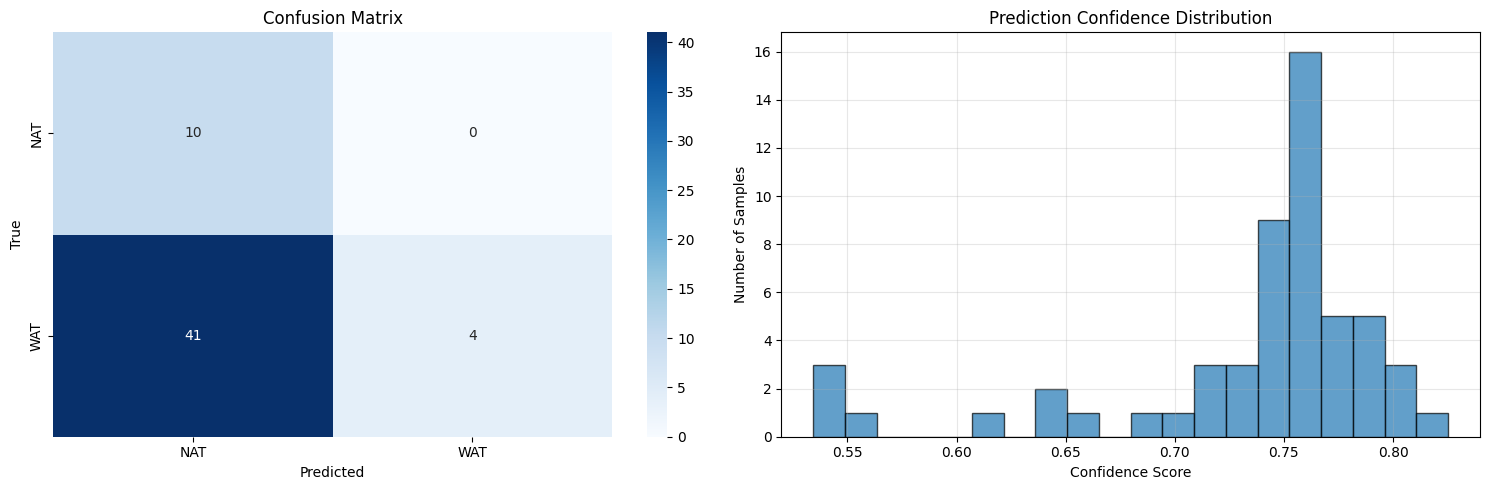


Confidence Statistics:
Mean confidence: 0.735
Median confidence: 0.755
Min confidence: 0.534
Max confidence: 0.825


In [9]:
# Visualize confusion matrix and results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Confidence distribution
axes[1].hist(df_results['confidence'], bins=20, alpha=0.7, edgecolor='black')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Number of Samples')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show confidence statistics
print(f"\nConfidence Statistics:")
print(f"Mean confidence: {df_results['confidence'].mean():.3f}")
print(f"Median confidence: {df_results['confidence'].median():.3f}")
print(f"Min confidence: {df_results['confidence'].min():.3f}")
print(f"Max confidence: {df_results['confidence'].max():.3f}")


Misclassified Samples: 41/55 (74.5%)

Misclassified samples details:
  J1220+5334: True=WAT, Predicted=NAT, Confidence=0.707
  J1459+5334: True=WAT, Predicted=NAT, Confidence=0.811
  J1120+5308: True=WAT, Predicted=NAT, Confidence=0.800
  J1147+5548: True=WAT, Predicted=NAT, Confidence=0.741
  J1224+4905: True=WAT, Predicted=NAT, Confidence=0.663
  J1523+5255: True=WAT, Predicted=NAT, Confidence=0.753
  J1359+4905: True=WAT, Predicted=NAT, Confidence=0.772
  J1238+4838: True=WAT, Predicted=NAT, Confidence=0.825
  J1208+5458: True=WAT, Predicted=NAT, Confidence=0.763
  J1431+4743: True=WAT, Predicted=NAT, Confidence=0.771
  J1127+5533: True=WAT, Predicted=NAT, Confidence=0.727
  J1121+5421: True=WAT, Predicted=NAT, Confidence=0.760
  J1057+4749: True=WAT, Predicted=NAT, Confidence=0.759
  J1249+4954: True=WAT, Predicted=NAT, Confidence=0.715
  J1224+5419: True=WAT, Predicted=NAT, Confidence=0.759
  J1325+5617: True=WAT, Predicted=NAT, Confidence=0.735
  J1247+4852: True=WAT, Predicted=

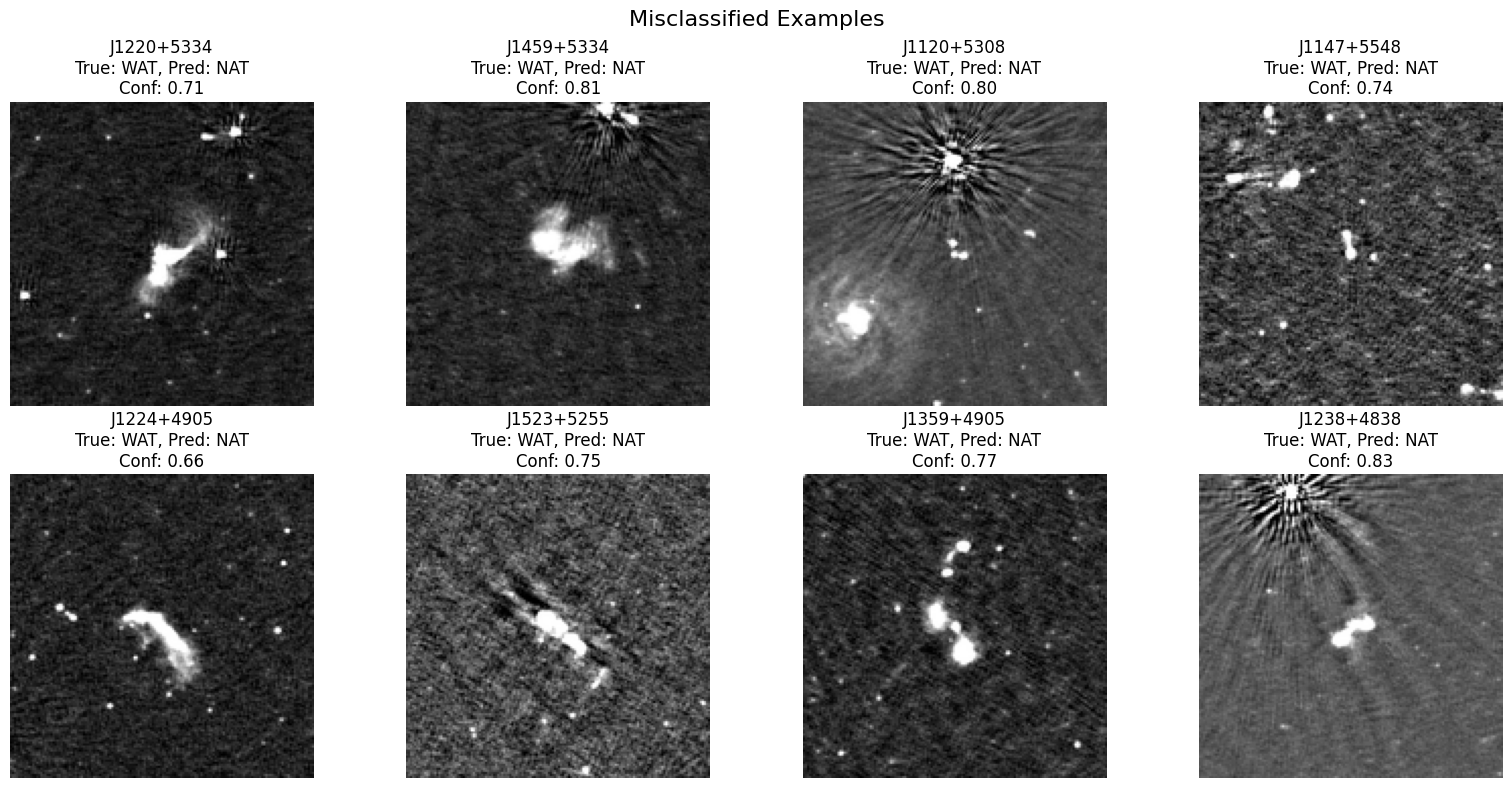

In [10]:
# Analyze misclassified samples
misclassified_mask = df_results['true_label'] != df_results['predicted_label']
misclassified = df_results[misclassified_mask].copy()

print(f"\nMisclassified Samples: {len(misclassified)}/{len(df_results)} ({len(misclassified)/len(df_results)*100:.1f}%)")

if len(misclassified) > 0:
    print("\nMisclassified samples details:")
    for _, row in misclassified.iterrows():
        print(f"  {row['agn_name']}: True={row['true_type']}, Predicted={row['predicted_type']}, "
              f"Confidence={row['confidence']:.3f}")
    
    # Show some misclassified examples
    n_show = min(8, len(misclassified))
    if n_show > 0:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()
        
        for i in range(n_show):
            idx = misclassified.index[i]
            img_idx = df_results.index.get_loc(idx)
            
            if img_idx < len(processed_images):
                img = processed_images[img_idx]
                row = misclassified.iloc[i]
                
                axes[i].imshow(img, cmap='gray')
                axes[i].set_title(f"{row['agn_name']}\nTrue: {row['true_type']}, "
                                f"Pred: {row['predicted_type']}\nConf: {row['confidence']:.2f}")
                axes[i].axis('off')
        
        # Hide unused subplots
        for i in range(n_show, 8):
            axes[i].axis('off')
            
        plt.suptitle('Misclassified Examples', fontsize=16)
        plt.tight_layout()
        plt.show()
else:
    print("No misclassifications found! Perfect accuracy!")


Correctly Classified Samples: 14/55
High-confidence correct predictions (>90%): 0


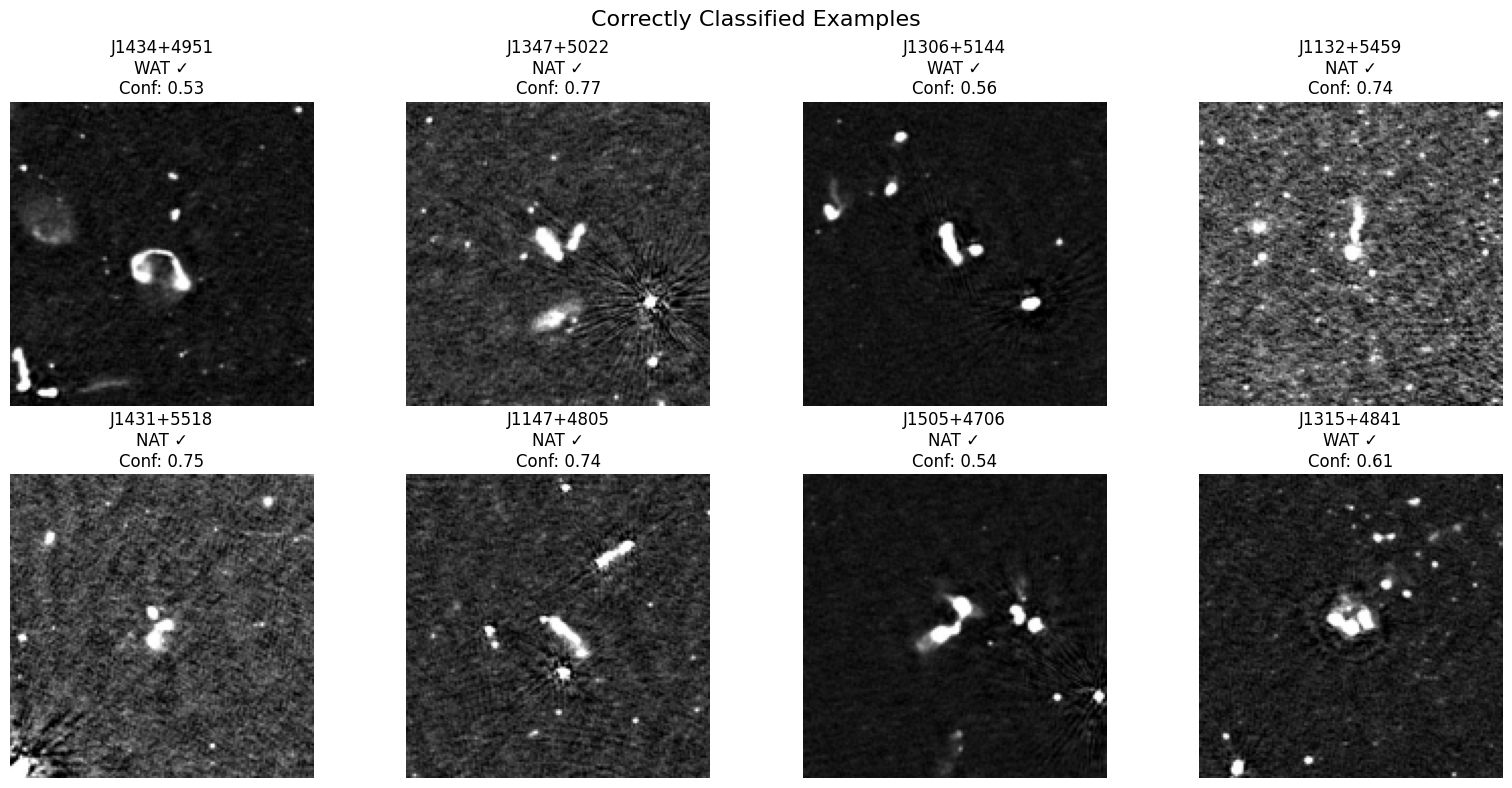

In [11]:
# Show some correctly classified examples for comparison
correctly_classified = df_results[~misclassified_mask].copy()

if len(correctly_classified) > 0:
    print(f"\nCorrectly Classified Samples: {len(correctly_classified)}/{len(df_results)}")
    
    # Show high-confidence correct predictions
    high_conf_correct = correctly_classified[correctly_classified['confidence'] > 0.9]
    print(f"High-confidence correct predictions (>90%): {len(high_conf_correct)}")
    
    # Show some examples
    n_show = min(8, len(correctly_classified))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i in range(n_show):
        idx = correctly_classified.index[i]
        img_idx = df_results.index.get_loc(idx)
        
        if img_idx < len(processed_images):
            img = processed_images[img_idx]
            row = correctly_classified.iloc[i]
            
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f"{row['agn_name']}\n{row['true_type']} ✓\n"
                            f"Conf: {row['confidence']:.2f}")
            axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(n_show, 8):
        axes[i].axis('off')
        
    plt.suptitle('Correctly Classified Examples', fontsize=16)
    plt.tight_layout()
    plt.show()

In [12]:
# Save results for further analysis
results_filename = 'agn_real_world_inference_results.csv'
df_results.to_csv(results_filename, index=False)
print(f"Results saved to {results_filename}")

# Create a summary report
summary = {
    'total_samples': len(df_results),
    'accuracy': accuracy,
    'true_NAT_count': (df_results['true_type'] == 'NAT').sum(),
    'true_WAT_count': (df_results['true_type'] == 'WAT').sum(),
    'predicted_NAT_count': (df_results['predicted_type'] == 'NAT').sum(), 
    'predicted_WAT_count': (df_results['predicted_type'] == 'WAT').sum(),
    'misclassified_count': len(misclassified),
    'mean_confidence': df_results['confidence'].mean(),
    'median_confidence': df_results['confidence'].median()
}

# Save summary
summary_filename = 'agn_real_world_performance_summary.txt'
with open(summary_filename, 'w') as f:
    f.write("AGN Real-World Classification Performance Summary\n")
    f.write("=" * 50 + "\n\n")
    for key, value in summary.items():
        f.write(f"{key.replace('_', ' ').title()}: {value}\n")
    f.write(f"\nClassification Report:\n")
    f.write(classification_report(true_labels, predicted_labels, target_names=class_names))

print(f"Summary saved to {summary_filename}")

# Final summary
print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Total AGN samples analyzed: {len(df_results)}")
print(f"Overall accuracy: {accuracy:.1%}")
print(f"Misclassified: {len(misclassified)} samples")
print(f"Mean confidence: {df_results['confidence'].mean():.3f}")
print("=" * 60)

Results saved to agn_real_world_inference_results.csv
Summary saved to agn_real_world_performance_summary.txt

FINAL RESULTS SUMMARY
Total AGN samples analyzed: 55
Overall accuracy: 25.5%
Misclassified: 41 samples
Mean confidence: 0.735


## Testing the Real AGN Trained Model

Now let's test the model that was trained on a subset of the real AGN data to see how it performs on the remaining real-world samples.

In [13]:
# Load the real AGN trained model
print("Loading real AGN trained model...")

# Create the model architecture (same as used in training)
real_trained_model = models.resnet18(pretrained=False)
real_trained_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = real_trained_model.fc.in_features
real_trained_model.fc = nn.Linear(num_ftrs, 2)
real_trained_model = real_trained_model.to(device)

# Load the trained weights
try:
    real_trained_model.load_state_dict(torch.load('best_real_agn_model.pth', map_location=device))
    real_trained_model.eval()
    print("✅ Real AGN trained model loaded successfully!")
except FileNotFoundError:
    print("❌ Real AGN model file not found. Please run the training in 03-CNN-training.ipynb first.")
    print("   Looking for: best_real_agn_model.pth")

Loading real AGN trained model...


/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Real AGN trained model loaded successfully!


In [14]:
# Run inference with the real AGN trained model
print("Running inference with real AGN trained model...")

real_predictions = []
real_probabilities = []

with torch.no_grad():
    for idx, row in df_results.iterrows():
        # Use the same processed image from before
        img_idx = df_results.index.get_loc(idx)
        
        if img_idx < len(processed_images):
            img = processed_images[img_idx]
            
            # Transform image (same as before)
            img_tensor = transform(img).unsqueeze(0).to(device)
            
            # Get model prediction
            output = real_trained_model(img_tensor)
            probabilities_raw = torch.softmax(output, dim=1)
            predicted_class = torch.argmax(output, dim=1).item()
            
            # Store results
            real_predictions.append(predicted_class)
            real_probabilities.append(probabilities_raw.cpu().numpy()[0])

# Add new predictions to dataframe
df_results['real_predicted_label'] = real_predictions
df_results['real_predicted_type'] = ['NAT' if pred == 0 else 'WAT' for pred in real_predictions]
df_results['real_prob_NAT'] = [prob[0] for prob in real_probabilities]
df_results['real_prob_WAT'] = [prob[1] for prob in real_probabilities]
df_results['real_confidence'] = [max(prob) for prob in real_probabilities]

print(f"✅ Inference completed on {len(df_results)} images!")

Running inference with real AGN trained model...
✅ Inference completed on 55 images!
✅ Inference completed on 55 images!


In [15]:
# Evaluate and compare both models
print("=" * 80)
print("MODEL COMPARISON: SYNTHETIC vs REAL AGN TRAINED")
print("=" * 80)

# Calculate metrics for both models
true_labels = df_results['true_label'].values
synthetic_preds = df_results['predicted_label'].values
real_agn_preds = df_results['real_predicted_label'].values

# Accuracies
synthetic_accuracy = (true_labels == synthetic_preds).sum() / len(true_labels)
real_agn_accuracy = (true_labels == real_agn_preds).sum() / len(true_labels)

# Confidences
synthetic_confidence = df_results['confidence'].mean()
real_agn_confidence = df_results['real_confidence'].mean()

print(f"SYNTHETIC MODEL (trained on CNN-Data):")
print(f"  Accuracy: {synthetic_accuracy:.3f} ({synthetic_accuracy*100:.1f}%)")
print(f"  Mean Confidence: {synthetic_confidence:.3f}")

print(f"\nREAL AGN MODEL (trained on real cutouts):")
print(f"  Accuracy: {real_agn_accuracy:.3f} ({real_agn_accuracy*100:.1f}%)")
print(f"  Mean Confidence: {real_agn_confidence:.3f}")

improvement = real_agn_accuracy - synthetic_accuracy
print(f"\nIMPROVEMENT: {improvement:.3f} ({improvement*100:.1f} percentage points)")

if improvement > 0:
    print("✅ Real AGN training SIGNIFICANTLY IMPROVED performance!")
elif improvement > -0.05:  # Small degradation
    print("≈ Performance is similar between models")
else:
    print("❌ Real AGN training decreased performance")

print("\nDetailed Comparison:")
print(f"Synthetic model predictions: {np.bincount(synthetic_preds)} (NAT, WAT)")
print(f"Real AGN model predictions: {np.bincount(real_agn_preds)} (NAT, WAT)")
print(f"True distribution: {np.bincount(true_labels)} (NAT, WAT)")
print("=" * 80)

MODEL COMPARISON: SYNTHETIC vs REAL AGN TRAINED
SYNTHETIC MODEL (trained on CNN-Data):
  Accuracy: 0.255 (25.5%)
  Mean Confidence: 0.735

REAL AGN MODEL (trained on real cutouts):
  Accuracy: 0.800 (80.0%)
  Mean Confidence: 0.796

IMPROVEMENT: 0.545 (54.5 percentage points)
✅ Real AGN training SIGNIFICANTLY IMPROVED performance!

Detailed Comparison:
Synthetic model predictions: [51  4] (NAT, WAT)
Real AGN model predictions: [19 36] (NAT, WAT)
True distribution: [10 45] (NAT, WAT)


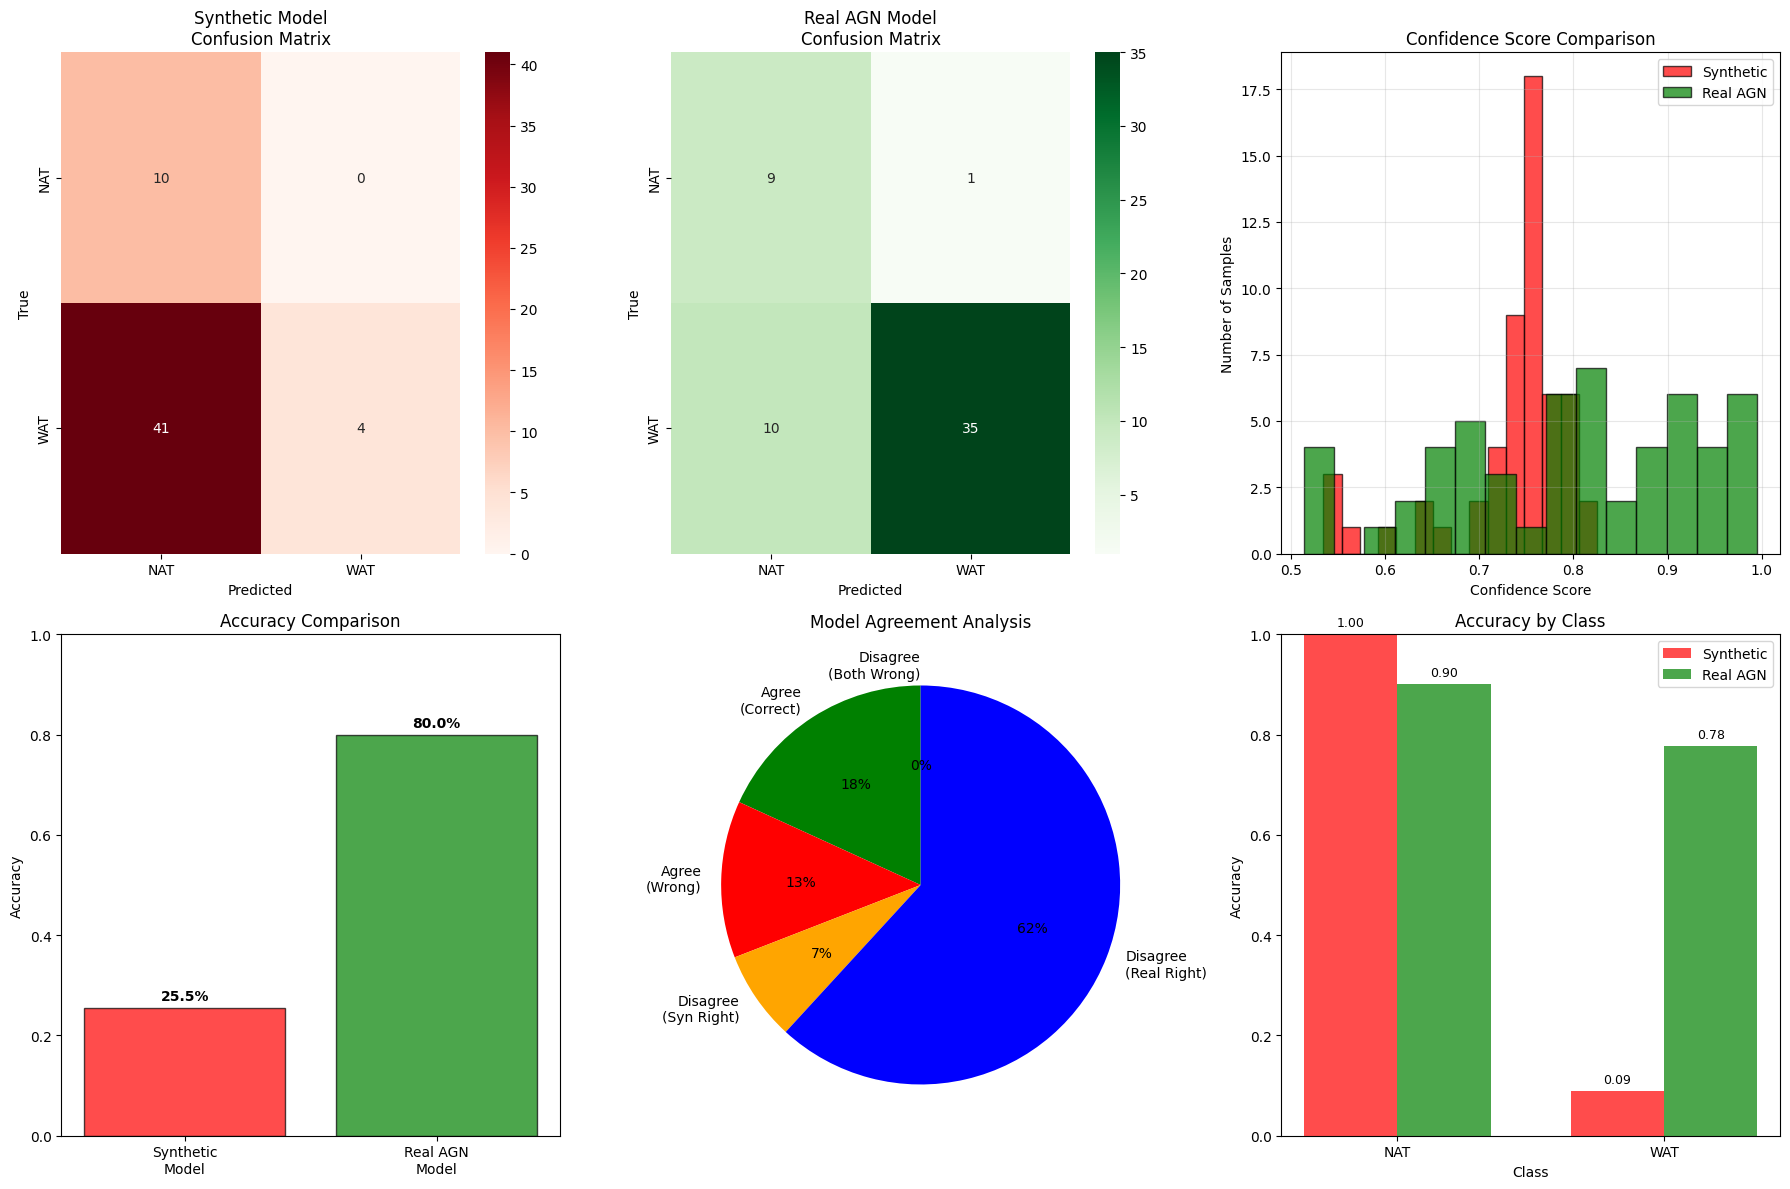

Model agreement: 17/55 samples (30.9%)


In [16]:
# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Confusion matrices
cm_synthetic = confusion_matrix(true_labels, synthetic_preds)
cm_real_agn = confusion_matrix(true_labels, real_agn_preds)

sns.heatmap(cm_synthetic, annot=True, fmt='d', cmap='Reds', 
           xticklabels=class_names, yticklabels=class_names, ax=axes[0,0])
axes[0,0].set_title('Synthetic Model\nConfusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('True')

sns.heatmap(cm_real_agn, annot=True, fmt='d', cmap='Greens', 
           xticklabels=class_names, yticklabels=class_names, ax=axes[0,1])
axes[0,1].set_title('Real AGN Model\nConfusion Matrix')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('True')

# Confidence distributions
axes[0,2].hist(df_results['confidence'], bins=15, alpha=0.7, 
               label='Synthetic', color='red', edgecolor='black')
axes[0,2].hist(df_results['real_confidence'], bins=15, alpha=0.7, 
               label='Real AGN', color='green', edgecolor='black')
axes[0,2].set_title('Confidence Score Comparison')
axes[0,2].set_xlabel('Confidence Score')
axes[0,2].set_ylabel('Number of Samples')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Accuracy comparison bar chart
model_names = ['Synthetic\nModel', 'Real AGN\nModel']
accuracies = [synthetic_accuracy, real_agn_accuracy]
colors = ['red', 'green']

bars = axes[1,0].bar(model_names, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[1,0].set_title('Accuracy Comparison')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_ylim(0, 1)

# Add accuracy values on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{acc:.1%}', ha='center', va='bottom', fontweight='bold')

# Agreement/disagreement analysis
agreement_mask = (synthetic_preds == real_agn_preds)
agree_correct = agreement_mask & (synthetic_preds == true_labels)
agree_wrong = agreement_mask & (synthetic_preds != true_labels)
disagree_synthetic_right = (~agreement_mask) & (synthetic_preds == true_labels)
disagree_real_agn_right = (~agreement_mask) & (real_agn_preds == true_labels)
disagree_both_wrong = (~agreement_mask) & (synthetic_preds != true_labels) & (real_agn_preds != true_labels)

agreement_counts = [
    agree_correct.sum(),
    agree_wrong.sum(),
    disagree_synthetic_right.sum(),
    disagree_real_agn_right.sum(),
    disagree_both_wrong.sum()
]

labels = ['Agree\n(Correct)', 'Agree\n(Wrong)', 'Disagree\n(Syn Right)', 
          'Disagree\n(Real Right)', 'Disagree\n(Both Wrong)']
colors = ['green', 'red', 'orange', 'blue', 'purple']

axes[1,1].pie(agreement_counts, labels=labels, colors=colors, autopct='%1.0f%%', startangle=90)
axes[1,1].set_title('Model Agreement Analysis')

# Performance by true class
nat_mask = (true_labels == 0)
wat_mask = (true_labels == 1)

nat_syn_acc = (synthetic_preds[nat_mask] == true_labels[nat_mask]).mean() if nat_mask.sum() > 0 else 0
nat_real_acc = (real_agn_preds[nat_mask] == true_labels[nat_mask]).mean() if nat_mask.sum() > 0 else 0
wat_syn_acc = (synthetic_preds[wat_mask] == true_labels[wat_mask]).mean() if wat_mask.sum() > 0 else 0
wat_real_acc = (real_agn_preds[wat_mask] == true_labels[wat_mask]).mean() if wat_mask.sum() > 0 else 0

x = np.arange(2)
width = 0.35

bars1 = axes[1,2].bar(x - width/2, [nat_syn_acc, wat_syn_acc], width, 
                     label='Synthetic', color='red', alpha=0.7)
bars2 = axes[1,2].bar(x + width/2, [nat_real_acc, wat_real_acc], width, 
                     label='Real AGN', color='green', alpha=0.7)

axes[1,2].set_title('Accuracy by Class')
axes[1,2].set_ylabel('Accuracy')
axes[1,2].set_xlabel('Class')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(['NAT', 'WAT'])
axes[1,2].legend()
axes[1,2].set_ylim(0, 1)

# Add values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1,2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Model agreement: {agreement_mask.sum()}/{len(agreement_mask)} samples ({agreement_mask.mean():.1%})")

In [17]:
# Save comprehensive comparison results
comparison_results = {
    'synthetic_accuracy': synthetic_accuracy,
    'real_agn_accuracy': real_agn_accuracy,
    'improvement': improvement,
    'synthetic_confidence': synthetic_confidence,
    'real_agn_confidence': real_agn_confidence,
    'agreement_rate': agreement_mask.mean(),
    'total_samples': len(df_results)
}

# Save updated results with both model predictions
comprehensive_results_filename = 'comprehensive_model_comparison_results.csv'
df_results.to_csv(comprehensive_results_filename, index=False)

# Create comprehensive summary report
comprehensive_summary_filename = 'comprehensive_model_performance_summary.txt'
with open(comprehensive_summary_filename, 'w') as f:
    f.write("Comprehensive AGN Classification Model Comparison\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("OVERVIEW:\n")
    f.write(f"Total samples analyzed: {len(df_results)}\n")
    f.write(f"True NAT count: {(true_labels == 0).sum()}\n")
    f.write(f"True WAT count: {(true_labels == 1).sum()}\n\n")
    
    f.write("SYNTHETIC MODEL PERFORMANCE:\n")
    f.write(f"Accuracy: {synthetic_accuracy:.3f} ({synthetic_accuracy*100:.1f}%)\n")
    f.write(f"Mean confidence: {synthetic_confidence:.3f}\n")
    f.write(f"Predicted NAT: {(synthetic_preds == 0).sum()}\n")
    f.write(f"Predicted WAT: {(synthetic_preds == 1).sum()}\n\n")
    
    f.write("REAL AGN MODEL PERFORMANCE:\n")
    f.write(f"Accuracy: {real_agn_accuracy:.3f} ({real_agn_accuracy*100:.1f}%)\n")
    f.write(f"Mean confidence: {real_agn_confidence:.3f}\n")
    f.write(f"Predicted NAT: {(real_agn_preds == 0).sum()}\n")
    f.write(f"Predicted WAT: {(real_agn_preds == 1).sum()}\n\n")
    
    f.write("COMPARISON:\n")
    f.write(f"Improvement: {improvement:.3f} ({improvement*100:.1f} percentage points)\n")
    f.write(f"Model agreement: {agreement_mask.sum()}/{len(agreement_mask)} ({agreement_mask.mean():.1%})\n\n")
    
    f.write("SYNTHETIC MODEL CLASSIFICATION REPORT:\n")
    f.write(classification_report(true_labels, synthetic_preds, target_names=class_names))
    f.write("\n\nREAL AGN MODEL CLASSIFICATION REPORT:\n")
    f.write(classification_report(true_labels, real_agn_preds, target_names=class_names))

print(f"✅ Comprehensive results saved to:")
print(f"   - {comprehensive_results_filename}")
print(f"   - {comprehensive_summary_filename}")

print(f"\n🎯 FINAL SUMMARY:")
print(f"   Real AGN model accuracy: {real_agn_accuracy:.1%}")
print(f"   Synthetic model accuracy: {synthetic_accuracy:.1%}")
print(f"   Performance improvement: {improvement*100:.1f} percentage points")
print(f"   Model weights used: best_real_agn_model.pth")

✅ Comprehensive results saved to:
   - comprehensive_model_comparison_results.csv
   - comprehensive_model_performance_summary.txt

🎯 FINAL SUMMARY:
   Real AGN model accuracy: 80.0%
   Synthetic model accuracy: 25.5%
   Performance improvement: 54.5 percentage points
   Model weights used: best_real_agn_model.pth
